# Phase 1 QC & Phase 2: Differential Expression Analysis

**Phase 1 (EDA):** Quick exploratory analysis of the pre-filtered TCGA-BRCA dataset — PCA, sample correlation, library sizes.

**Phase 2 (DEA):** Differential expression with PyDESeq2 — each subtype vs Normal, volcano plots, and top-DEG heatmap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
import warnings, os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Load pre-filtered data
exp_raw = pd.read_pickle("exp_data_filtered.pkl")
metadata  = pd.read_pickle("metadata.pkl")

# Deduplicate gene names — keep the row with the highest mean expression
n_before = exp_raw.shape[0]
exp_raw["_mean"] = exp_raw.mean(axis=1, numeric_only=True)
exp = (exp_raw
       .reset_index()
       .sort_values("_mean", ascending=False)
       .drop_duplicates(subset="gene_name", keep="first")
       .drop(columns=["_mean"])
       .set_index("gene_name"))
n_after = exp.shape[0]

print(f"Expression matrix : {n_before:,} → {n_after:,} genes after deduplication ({n_before - n_after:,} removed)")
print(f"                    {exp.shape[1]} samples")
assert exp.index.is_unique, "Gene index still has duplicates!"

# Consistent palette used throughout all notebooks
SUBTYPE_COLORS = {
    "LumA": "#1f77b4", "LumB": "#ff7f0e",
    "Basal": "#d62728", "Her2": "#9467bd", "Normal": "#2ca02c",
}
SUBTYPE_ORDER = ["Basal", "Her2", "LumA", "LumB", "Normal"]

print(f"\nSubtype counts:\n{metadata['subtype'].value_counts().loc[SUBTYPE_ORDER]}")

Expression matrix : 60,660 → 59,427 genes after deduplication (1,233 removed)
                    1118 samples

Subtype counts:
subtype
Basal     181
Her2       77
LumA      528
LumB      198
Normal    134
Name: count, dtype: int64


---
## Phase 1 — Exploratory Data Analysis

### 1.1 Library Size Distribution

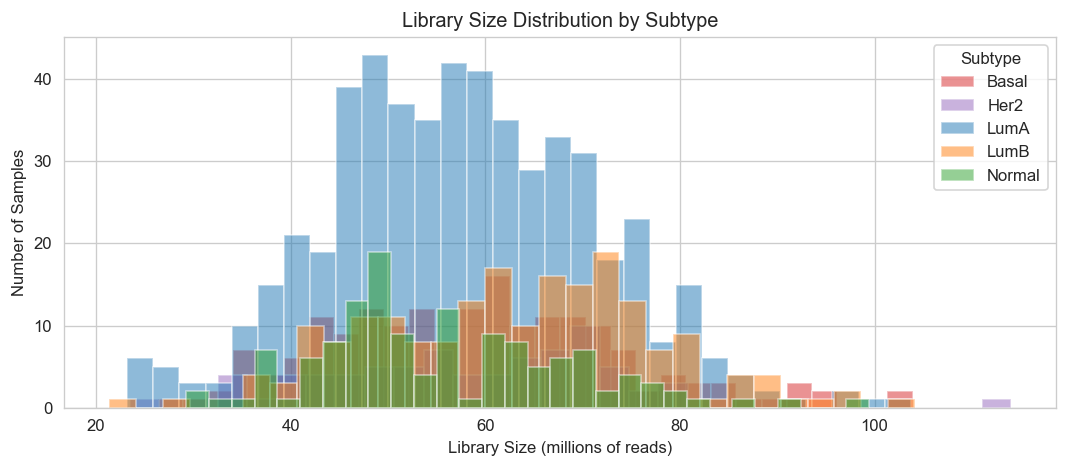

Range: 21.3M – 114.0M | Median: 58.1M


In [2]:
lib_sizes = exp.sum(axis=0)
lib_df = pd.DataFrame({"library_size": lib_sizes}).join(metadata)

fig, ax = plt.subplots(figsize=(9, 4))
for st in SUBTYPE_ORDER:
    vals = lib_df.loc[lib_df["subtype"] == st, "library_size"] / 1e6
    ax.hist(vals, bins=30, alpha=0.5, label=st, color=SUBTYPE_COLORS[st])
ax.set_xlabel("Library Size (millions of reads)")
ax.set_ylabel("Number of Samples")
ax.set_title("Library Size Distribution by Subtype")
ax.legend(title="Subtype")
plt.tight_layout()
plt.savefig("figures/library_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Range: {lib_sizes.min()/1e6:.1f}M – {lib_sizes.max()/1e6:.1f}M | Median: {lib_sizes.median()/1e6:.1f}M")

### 1.2 PCA — Subtype Clustering

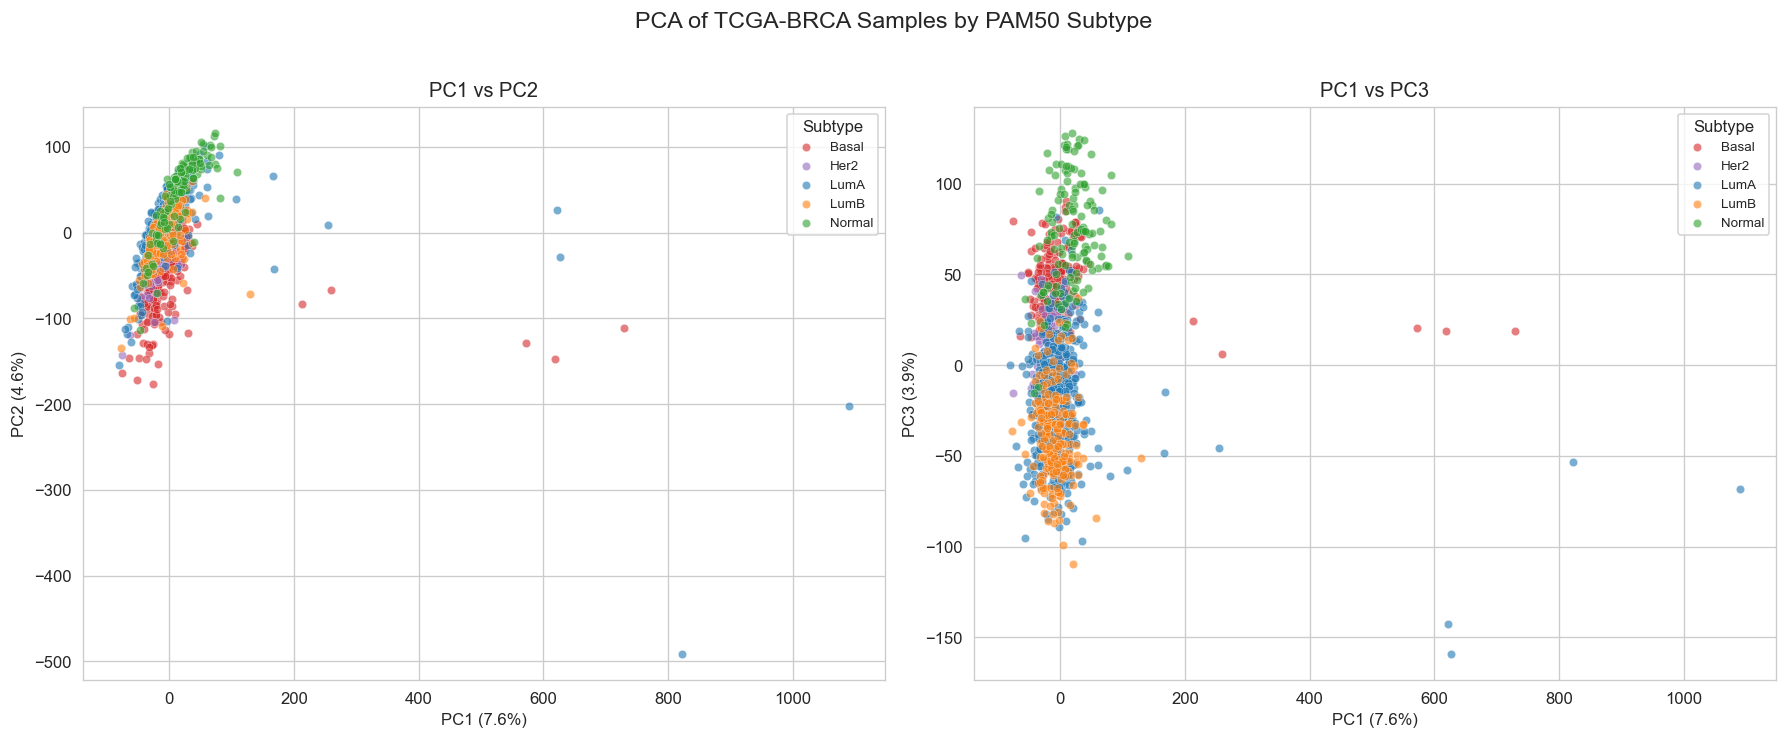

Cumulative variance (top 10 PCs): 29.7%


In [3]:
# log2-CPM for visualization only
cpm = exp.div(exp.sum(axis=0), axis=1) * 1e6
log2_cpm = np.log2(cpm + 1)

# PCA on standardized log2-CPM
X_scaled = StandardScaler().fit_transform(log2_cpm.T)  # samples × genes
pca = PCA(n_components=10).fit(X_scaled)
pcs = pca.transform(X_scaled)
var_pct = pca.explained_variance_ratio_ * 100

pc_df = pd.DataFrame(pcs[:, :3], columns=["PC1", "PC2", "PC3"], index=exp.columns).join(metadata)

# PC1 vs PC2
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for st in SUBTYPE_ORDER:
    m = pc_df["subtype"] == st
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"],
                    c=SUBTYPE_COLORS[st], label=st, alpha=0.6, s=25, edgecolors="white", linewidths=0.3)
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC3"],
                    c=SUBTYPE_COLORS[st], label=st, alpha=0.6, s=25, edgecolors="white", linewidths=0.3)

axes[0].set_xlabel(f"PC1 ({var_pct[0]:.1f}%)"); axes[0].set_ylabel(f"PC2 ({var_pct[1]:.1f}%)")
axes[0].set_title("PC1 vs PC2"); axes[0].legend(title="Subtype", fontsize=8)
axes[1].set_xlabel(f"PC1 ({var_pct[0]:.1f}%)"); axes[1].set_ylabel(f"PC3 ({var_pct[2]:.1f}%)")
axes[1].set_title("PC1 vs PC3"); axes[1].legend(title="Subtype", fontsize=8)
plt.suptitle("PCA of TCGA-BRCA Samples by PAM50 Subtype", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/pca_subtypes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Cumulative variance (top 10 PCs): {var_pct.sum():.1f}%")

### 1.3 Sample Correlation Heatmap

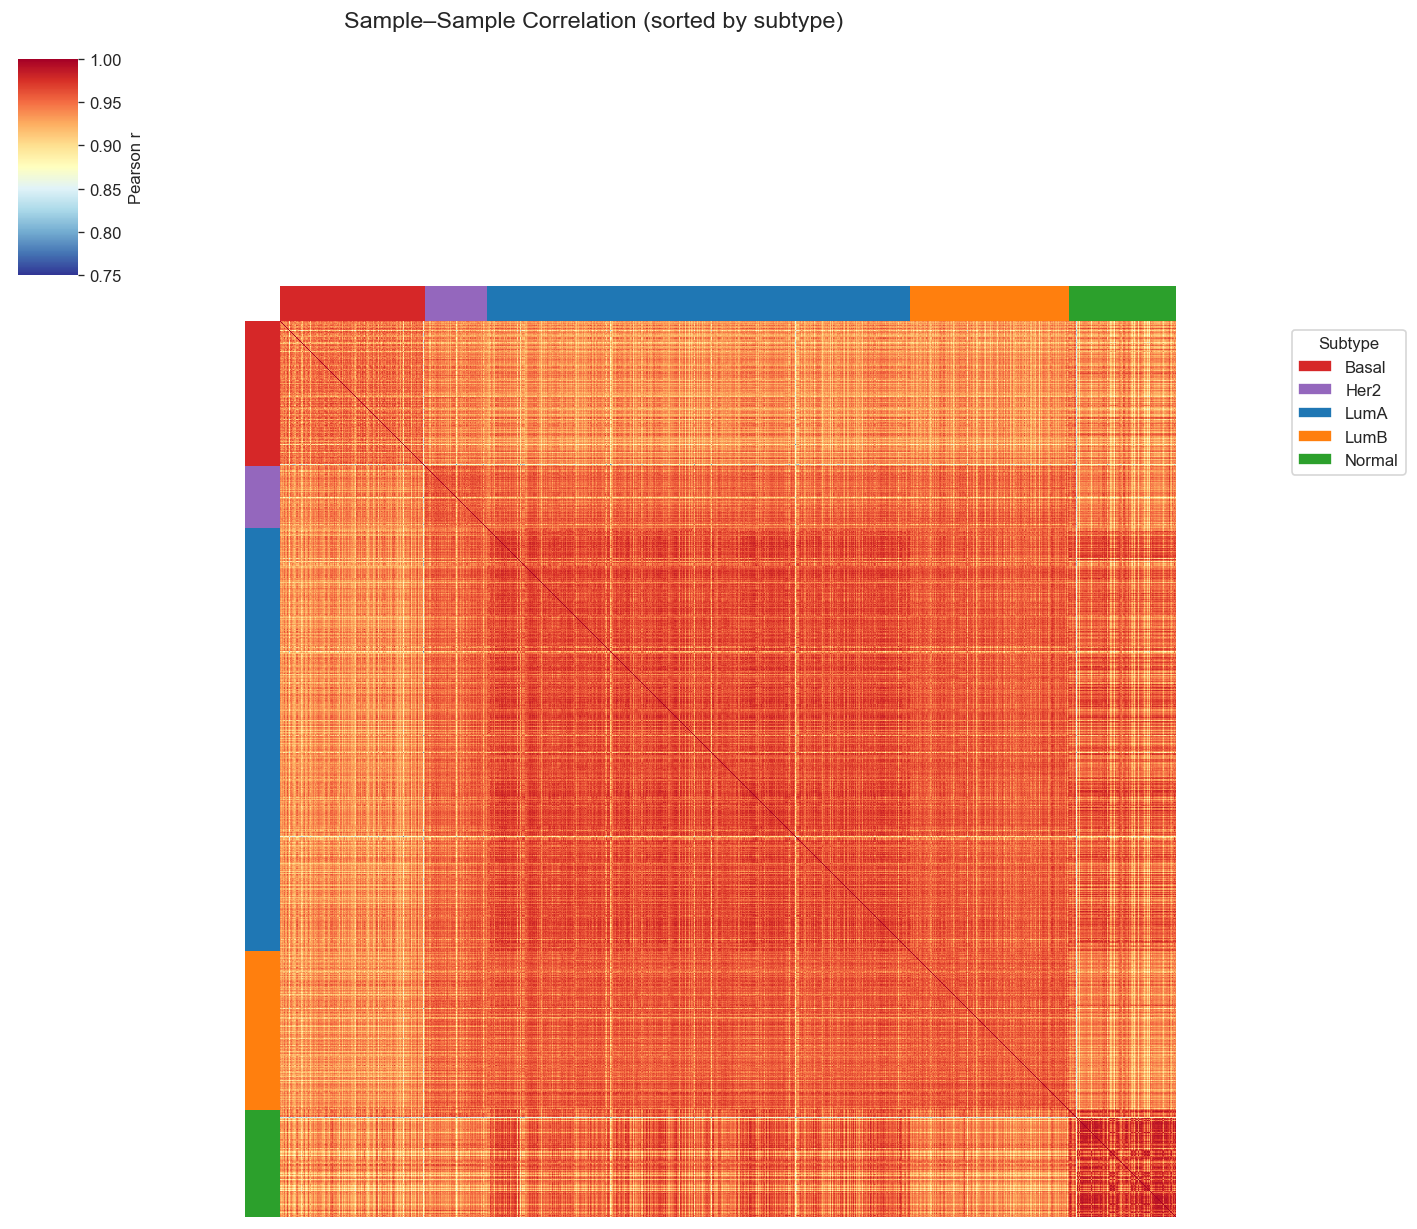

In [4]:
# Sort samples by subtype for block-diagonal structure
sorted_meta = metadata.loc[exp.columns].copy()
sorted_meta["subtype"] = pd.Categorical(sorted_meta["subtype"], categories=SUBTYPE_ORDER, ordered=True)
sorted_meta = sorted_meta.sort_values("subtype")
sorted_ids = sorted_meta.index.tolist()

corr = log2_cpm[sorted_ids].corr()
row_colors = sorted_meta["subtype"].map(SUBTYPE_COLORS)

g = sns.clustermap(
    corr, row_cluster=False, col_cluster=False,
    row_colors=row_colors.values, col_colors=row_colors.values,
    cmap="RdYlBu_r", vmin=0.75, vmax=1.0, figsize=(10, 10),
    xticklabels=False, yticklabels=False, cbar_kws={"label": "Pearson r"},
)
g.fig.suptitle("Sample–Sample Correlation (sorted by subtype)", y=1.02, fontsize=14)
legend_handles = [Patch(facecolor=SUBTYPE_COLORS[s], label=s) for s in SUBTYPE_ORDER]
g.ax_heatmap.legend(handles=legend_handles, title="Subtype", loc="upper left",
                    bbox_to_anchor=(1.12, 1.0), frameon=True)
plt.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 2 — Differential Expression Analysis (PyDESeq2)

For each tumor subtype (Basal, Her2, LumA, LumB) we run a two-group comparison against Normal tissue using PyDESeq2. Significance thresholds: **|log₂FC| > 1.5** and **adjusted p-value < 0.01**.

In [5]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

LFC_THRESH = 1.5
PADJ_THRESH = 0.01

tumor_subtypes = ["Basal", "Her2", "LumA", "LumB"]
deg_results = {}  # subtype → DataFrame of DESeq2 results

for subtype in tumor_subtypes:
    print(f"\n{'='*60}")
    print(f"  Running DESeq2: {subtype} vs Normal")
    print(f"{'='*60}")

    # Subset to this subtype + Normal samples
    samples = metadata[metadata["subtype"].isin([subtype, "Normal"])].index
    counts_sub = exp[samples].T  # PyDESeq2 wants samples × genes
    counts_sub = counts_sub.astype(int)

    clinical_sub = metadata.loc[samples].copy()
    clinical_sub["condition"] = clinical_sub["subtype"].apply(lambda x: "Tumor" if x == subtype else "Normal")

    print(f"  Samples: {(clinical_sub['condition']=='Tumor').sum()} Tumor, "
          f"{(clinical_sub['condition']=='Normal').sum()} Normal")

    # Build DESeq2 dataset
    dds = DeseqDataSet(
        counts=counts_sub,
        metadata=clinical_sub,
        design="~condition",
        ref_level=["condition", "Normal"],
        quiet=True,
    )
    dds.deseq2()

    # Statistical testing
    stat_res = DeseqStats(dds, contrast=["condition", "Tumor", "Normal"], quiet=True)
    stat_res.summary()
    res_df = stat_res.results_df.copy()

    # Flag significant DEGs
    res_df["significant"] = (res_df["padj"] < PADJ_THRESH) & (res_df["log2FoldChange"].abs() > LFC_THRESH)
    n_up = ((res_df["significant"]) & (res_df["log2FoldChange"] > 0)).sum()
    n_down = ((res_df["significant"]) & (res_df["log2FoldChange"] < 0)).sum()

    print(f"  DEGs: {n_up} up, {n_down} down ({n_up + n_down} total)")

    deg_results[subtype] = res_df

print("\nAll comparisons complete.")


  Running DESeq2: Basal vs Normal
  Samples: 181 Tumor, 134 Normal
  DEGs: 3723 up, 2880 down (6603 total)

  Running DESeq2: Her2 vs Normal
  Samples: 77 Tumor, 134 Normal
  DEGs: 2700 up, 3672 down (6372 total)

  Running DESeq2: LumA vs Normal
  Samples: 528 Tumor, 134 Normal
  DEGs: 1738 up, 2806 down (4544 total)

  Running DESeq2: LumB vs Normal
  Samples: 198 Tumor, 134 Normal
  DEGs: 2461 up, 4276 down (6737 total)

All comparisons complete.


### 2.1 Volcano Plots

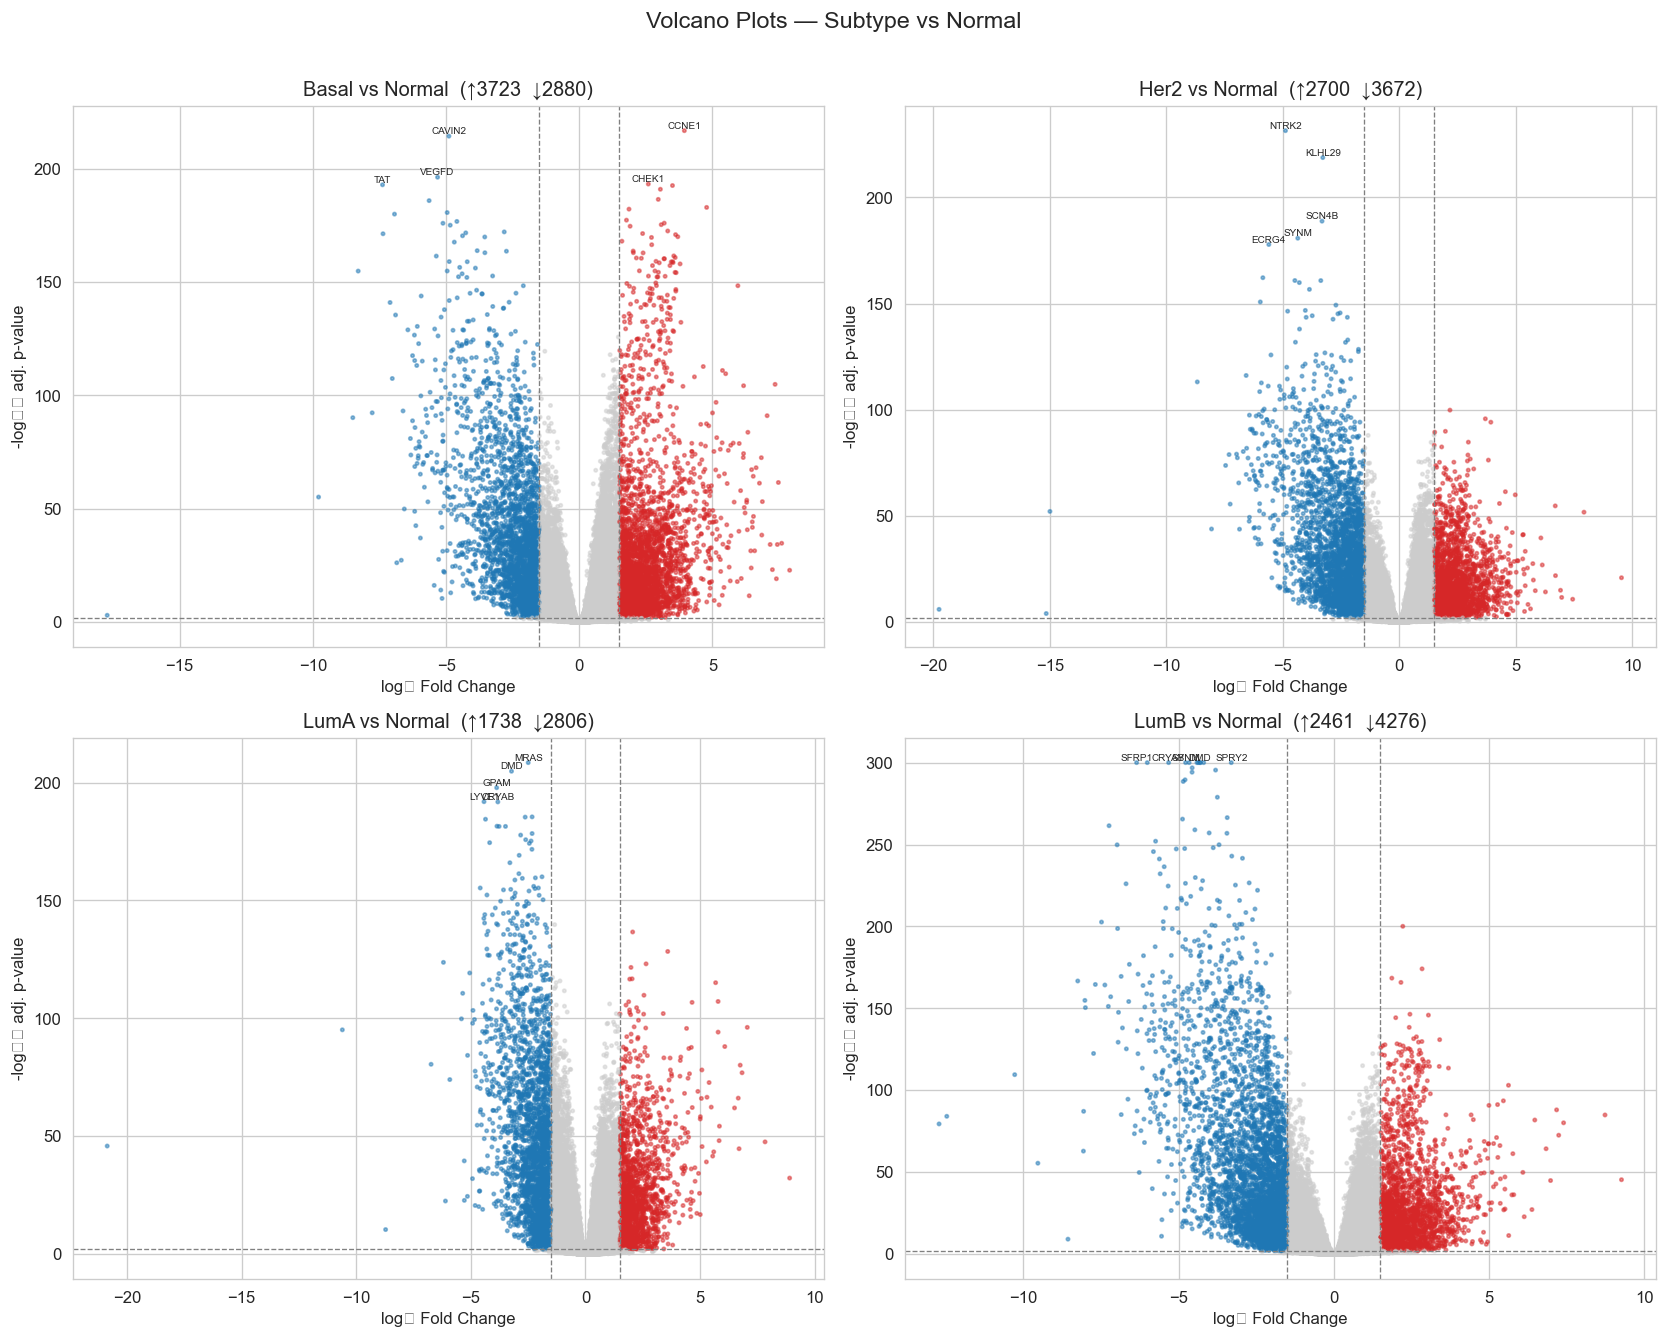

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, subtype in zip(axes.flatten(), tumor_subtypes):
    df = deg_results[subtype].dropna(subset=["padj", "log2FoldChange"]).copy()
    df["-log10padj"] = -np.log10(df["padj"].clip(lower=1e-300))

    # Color: grey=NS, blue=down, red=up
    colors = np.where(
        df["significant"] & (df["log2FoldChange"] > 0), "#d62728",
        np.where(df["significant"] & (df["log2FoldChange"] < 0), "#1f77b4", "#cccccc")
    )

    ax.scatter(df["log2FoldChange"], df["-log10padj"], c=colors, s=4, alpha=0.5)
    ax.axhline(-np.log10(PADJ_THRESH), color="grey", ls="--", lw=0.8)
    ax.axvline(-LFC_THRESH, color="grey", ls="--", lw=0.8)
    ax.axvline(LFC_THRESH, color="grey", ls="--", lw=0.8)

    n_up = ((df["significant"]) & (df["log2FoldChange"] > 0)).sum()
    n_down = ((df["significant"]) & (df["log2FoldChange"] < 0)).sum()
    ax.set_title(f"{subtype} vs Normal  (↑{n_up}  ↓{n_down})", fontsize=12)
    ax.set_xlabel("log₂ Fold Change")
    ax.set_ylabel("-log₁₀ adj. p-value")

    # Label top 5 DEGs by significance
    top_genes = df.loc[df["significant"]].nlargest(5, "-log10padj")
    for _, row in top_genes.iterrows():
        ax.annotate(row.name, (row["log2FoldChange"], row["-log10padj"]),
                    fontsize=6, ha="center", va="bottom")

plt.suptitle("Volcano Plots — Subtype vs Normal", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/volcano_plots.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 DEG Summary Table

In [7]:
# Summary table
summary_rows = []
for subtype in tumor_subtypes:
    df = deg_results[subtype]
    sig = df[df["significant"]]
    summary_rows.append({
        "Subtype": subtype,
        "Total Genes Tested": len(df),
        "DEGs (up)": (sig["log2FoldChange"] > 0).sum(),
        "DEGs (down)": (sig["log2FoldChange"] < 0).sum(),
        "DEGs (total)": len(sig),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Subtype")
print(summary_df.to_string())

# Save individual DEG lists
for subtype in tumor_subtypes:
    sig = deg_results[subtype][deg_results[subtype]["significant"]].sort_values("padj")
    sig.to_csv(f"results/DEGs_{subtype}_vs_Normal.csv")

print(f"\nDEG lists saved to results/ directory.")

         Total Genes Tested  DEGs (up)  DEGs (down)  DEGs (total)
Subtype                                                          
Basal                 59427       3723         2880          6603
Her2                  59427       2700         3672          6372
LumA                  59427       1738         2806          4544
LumB                  59427       2461         4276          6737

DEG lists saved to results/ directory.


### 2.3 Heatmap of Top DEGs Across All Subtypes

We take the union of the top 25 DEGs (by adjusted p-value) from each subtype comparison and visualize their log₂-CPM expression across all samples.

Union of top DEGs: 84 genes


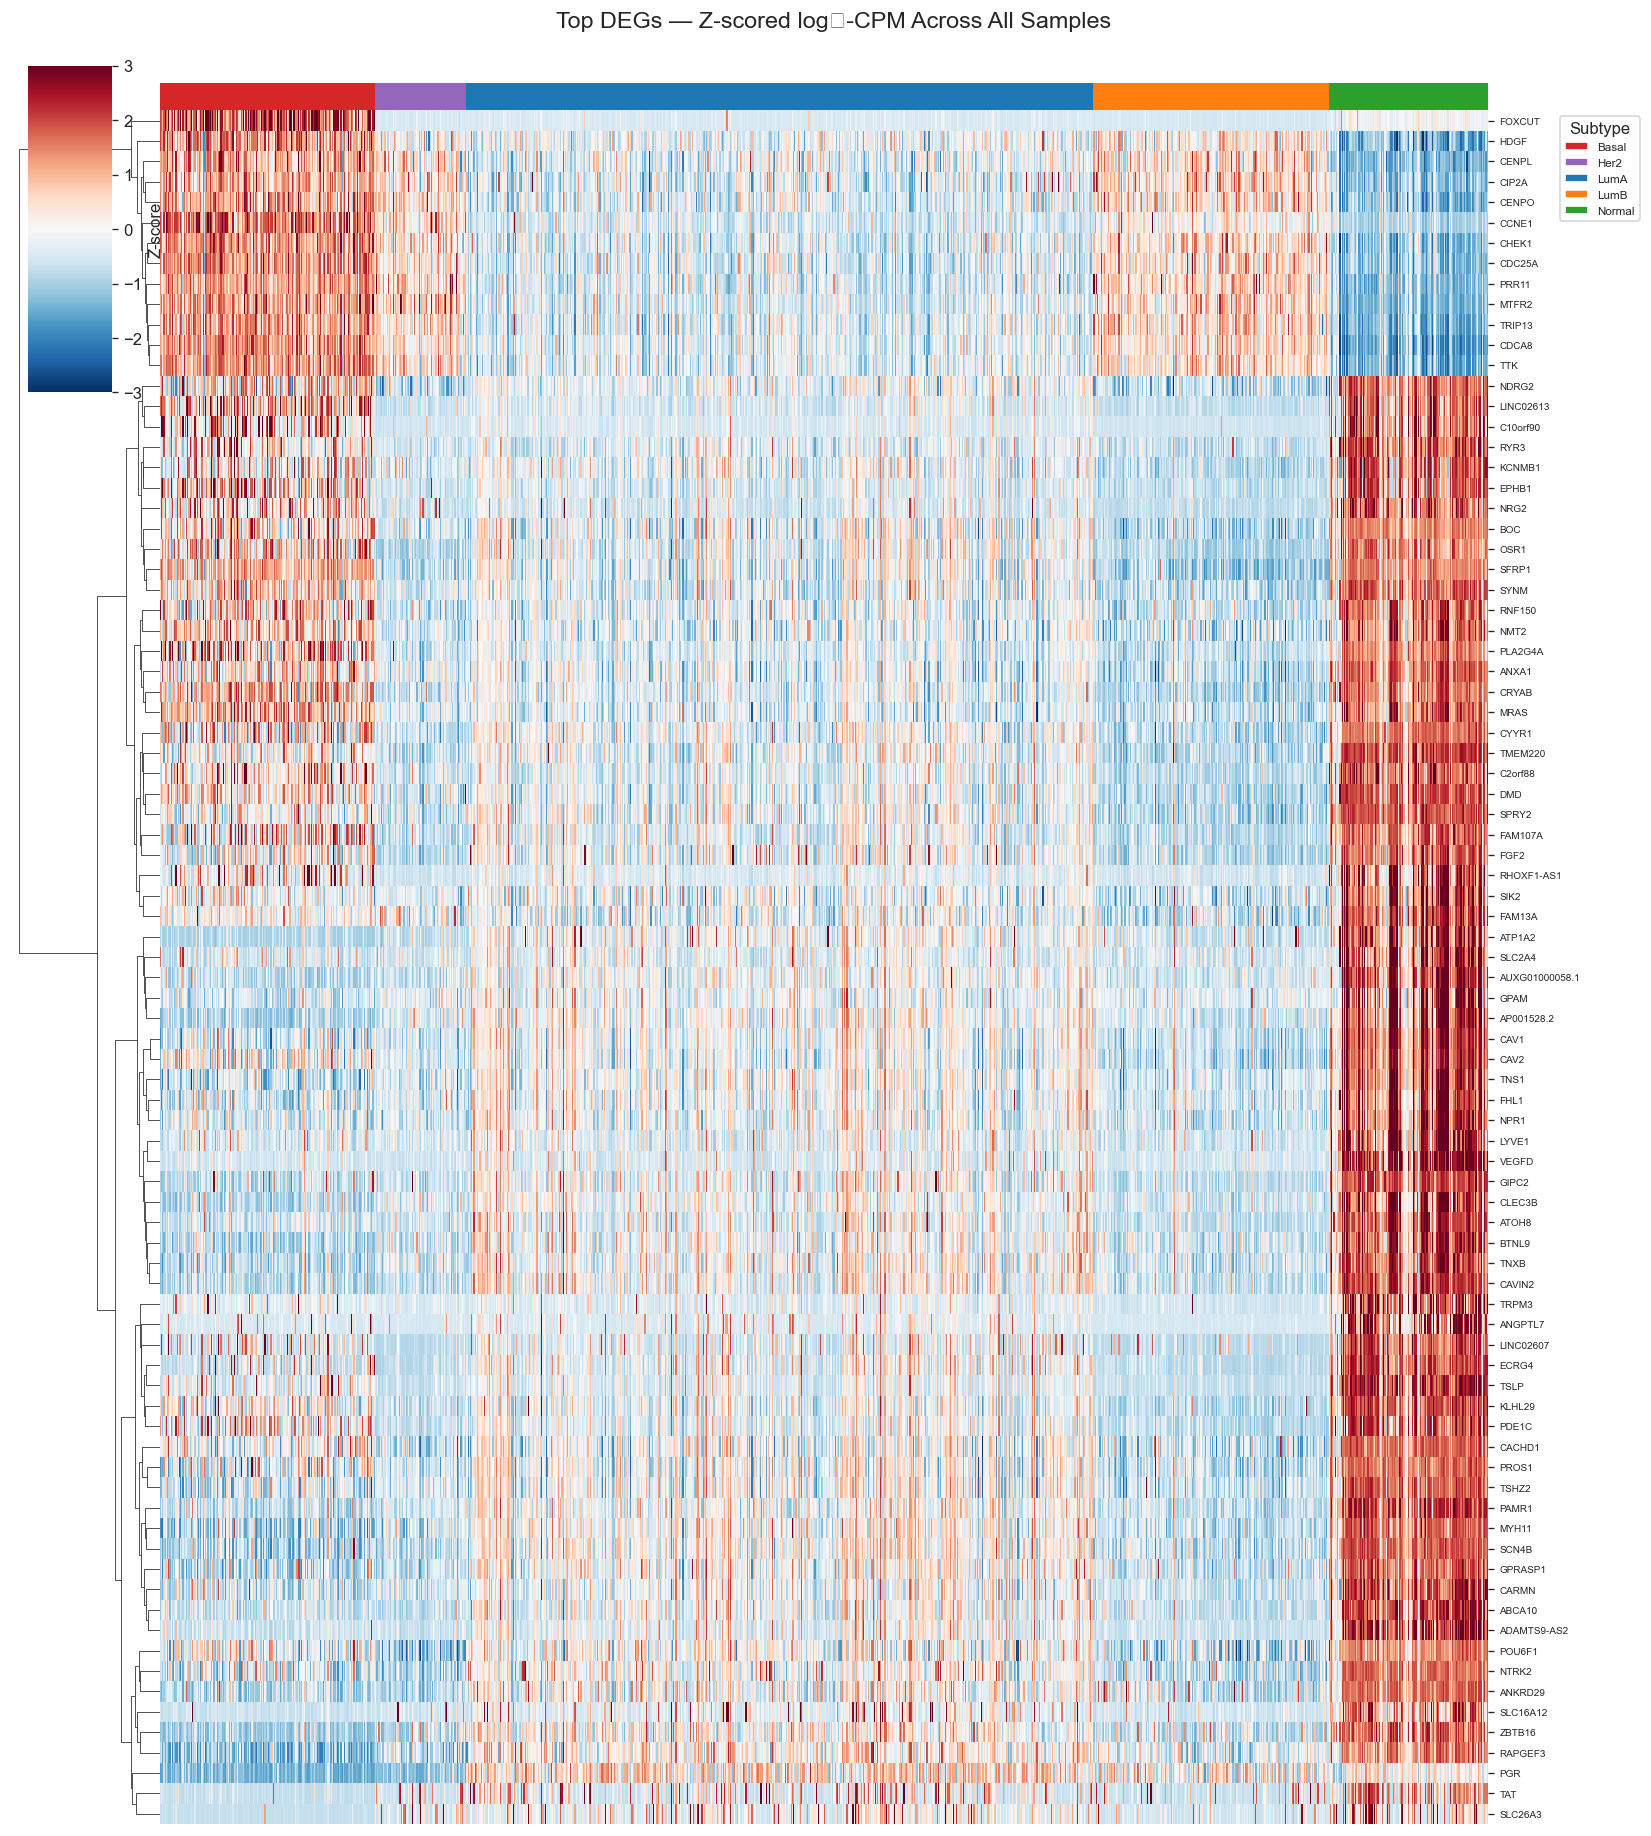

In [8]:
# Collect top 25 significant DEGs per subtype
top_genes_set = set()
for subtype in tumor_subtypes:
    sig = deg_results[subtype][deg_results[subtype]["significant"]].sort_values("padj")
    top_genes_set.update(sig.head(25).index)

top_genes = sorted(top_genes_set)
print(f"Union of top DEGs: {len(top_genes)} genes")

# Z-score normalized log2-CPM for heatmap
heatmap_data = log2_cpm.loc[log2_cpm.index.isin(top_genes), sorted_ids]
heatmap_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)

col_colors = sorted_meta["subtype"].map(SUBTYPE_COLORS)

g = sns.clustermap(
    heatmap_z, col_cluster=False, row_cluster=True, method="ward",
    cmap="RdBu_r", vmin=-3, vmax=3, figsize=(14, max(8, len(top_genes) * 0.18)),
    col_colors=col_colors.values, xticklabels=False,
    yticklabels=True, cbar_kws={"label": "Z-score"},
    dendrogram_ratio=(0.1, 0.02), colors_ratio=0.015,
)
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.tick_params(axis="y", labelsize=6)
g.fig.suptitle("Top DEGs — Z-scored log₂-CPM Across All Samples", y=1.01, fontsize=14)
legend_handles = [Patch(facecolor=SUBTYPE_COLORS[s], label=s) for s in SUBTYPE_ORDER]
g.ax_heatmap.legend(handles=legend_handles, title="Subtype", loc="upper left",
                    bbox_to_anchor=(1.05, 1.0), frameon=True, fontsize=7)
plt.savefig("figures/top_degs_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Subtype-Specific vs Shared DEGs (UpSet-style summary)

In [9]:
# Venn-style summary: how many DEGs are unique to each subtype vs shared?
deg_sets = {}
for subtype in tumor_subtypes:
    deg_sets[subtype] = set(deg_results[subtype][deg_results[subtype]["significant"]].index)

# Build membership matrix
all_degs = sorted(set.union(*deg_sets.values()))
membership = pd.DataFrame(
    {st: [g in deg_sets[st] for g in all_degs] for st in tumor_subtypes},
    index=all_degs
)

# Count genes unique to each subtype and shared across all
for st in tumor_subtypes:
    unique = membership[membership[st] & ~membership.drop(columns=st).any(axis=1)]
    print(f"{st}-specific DEGs: {len(unique)}")

shared_all = membership[membership.all(axis=1)]
print(f"\nShared across ALL 4 subtypes: {len(shared_all)}")
print(f"Total unique DEGs (union): {len(all_degs)}")

# Save full DEG results (all genes, not just significant) for Phase 3
for subtype in tumor_subtypes:
    deg_results[subtype].to_csv(f"results/DESeq2_full_{subtype}_vs_Normal.csv")
print("\nFull DESeq2 results saved to results/ directory.")

Basal-specific DEGs: 2517
Her2-specific DEGs: 1179
LumA-specific DEGs: 290
LumB-specific DEGs: 1016

Shared across ALL 4 subtypes: 1611
Total unique DEGs (union): 11786

Full DESeq2 results saved to results/ directory.
